In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


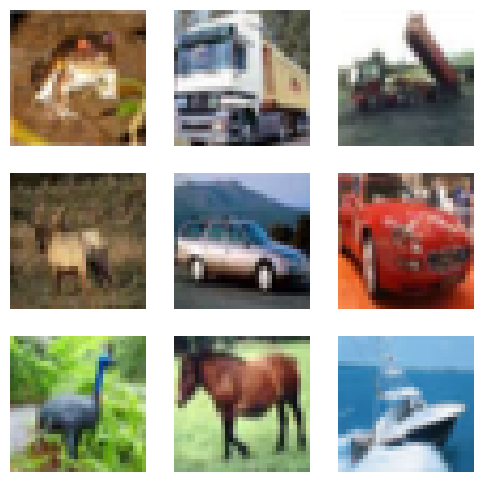

In [6]:
#visualizing images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
#model
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
#train model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 263s 334ms/step - accuracy: 0.4137 - loss: 1.5915 - val_accuracy: 0.5804 - val_loss: 1.1627
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 269s 342ms/step - accuracy: 0.6133 - loss: 1.0882 - val_accuracy: 0.6764 - val_loss: 0.9247
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 266s 340ms/step - accuracy: 0.6924 - loss: 0.8804 - val_accuracy: 0.7262 - val_loss: 0.7910
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 265s 339ms/step - accuracy: 0.7382 - loss: 0.7511 - val_accuracy: 0.7497 - val_loss: 0.7170
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 266s 341ms/step - accuracy: 0.7694 - loss: 0.6637 - val_accuracy: 0.7652 - val_loss: 0.6818
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 261s 334ms/step - accuracy: 0.7974 - loss: 0.5845 - val_accuracy: 0.7559 - val_loss: 0.7124
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 258s 330ms/step - accuracy: 0.8141 - loss: 0.5281 - val_accuracy: 0.7773 - val_loss: 0.6647
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 265s 334ms/step - accuracy: 0.8333 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7847 - loss: 0.6871
Test Accuracy: 0.7846999764442444


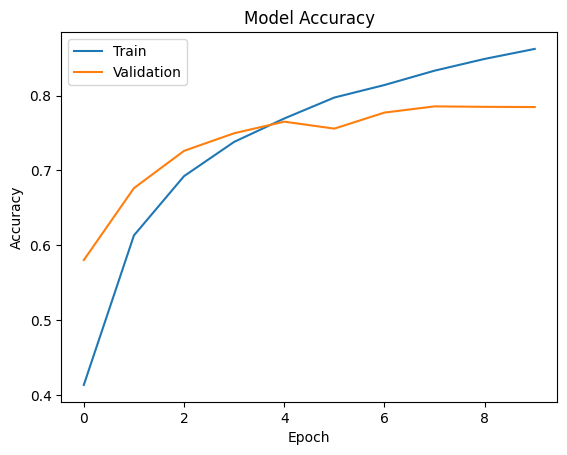

In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [12]:
prediction = model.predict(x_test[0].reshape(1,32,32,3))

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted Class: 3
Actual Class: 3
